In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import os, sys
import pandas as pd

# Get the absolute path to the src directory
src_path = os.path.abspath(os.path.join(os.getcwd(), "../"))

# Add src_path to the system path
sys.path.insert(0, src_path)

from utils import mappings


INPUT_PATH = "../../data/processed/4_1_international_proportion_temporal.csv"
YEARS = [str(i) for i in range(2015, 2025)]

In [18]:
def plot_international_trends(df, years, total_publications, top5_highest=True, top5_by_volume=True):
    """
    Create a plot showing either the top 5 or bottom 5 subfields by publication volume or collaboration percentage.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with subfields as rows and years as columns, containing international percentages
    years : list
        List of years to plot
    total_publications : pandas.Series
        Series with total publications per subfield (from temporal data)
    top5_highest : bool, optional
        If True, show highest values; if False, show lowest. Default is True.
    top5_by_volume : bool, optional
        If True, select by publication volume; if False, select by collaboration percentage.
        Default is True.
    """
    # Set seaborn's research paper theme
    sns.set_theme(style="whitegrid", context="paper", font_scale=2.2)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(16, 8))

    # Select subfields based on criteria
    if top5_by_volume:
        # Sort by total publications
        sorted_subfields = total_publications.sort_values(ascending=not top5_highest)
        title_suffix = "Highest Publication Volume" if top5_highest else "Lowest Publication Volume"
    else:
        # Sort by average collaboration percentage
        df['Average'] = df[years].mean(axis=1)
        sorted_subfields = df['Average'].sort_values(ascending=not top5_highest)
        title_suffix = "Highest International Collaboration" if top5_highest else "Lowest International Collaboration"

    selected_subfields = sorted_subfields.index[:5]

    # Plot selected subfields
    for subfield in selected_subfields:
        short_label = mappings.SUBFIELDS_SHORT.get(subfield, subfield)
        color = mappings.COLOUR_PALETTE.get(short_label, None)
        marker = mappings.MARKERS.get(short_label, "o")
        
        ax.plot(
            years,
            df.loc[subfield, years],
            marker=marker,
            linewidth=2,
            markersize=8,
            color=color,
            label=short_label,
        )

    # Configure plot
    ax.grid(True, linestyle="--", alpha=0.7)
    ax.set_xlabel("Year")
    ax.set_ylabel("International Publications (%)")
    ax.set_xticks(years)
    ax.set_xticklabels(years)
    ax.set_ylim(0, 50)

    # Create sorted legend
    handles, labels = ax.get_legend_handles_labels()
    sorted_handles_labels = sorted(zip(labels, handles), key=lambda x: x[0])
    sorted_labels, sorted_handles = zip(*sorted_handles_labels)

    ax.legend(
        sorted_handles,
        sorted_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=5,
        title="Subfields",
        frameon=True,
    )

    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 0.93])

    plt.savefig(
        fname="../../results/figures/international_collaboration_trends.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    return fig

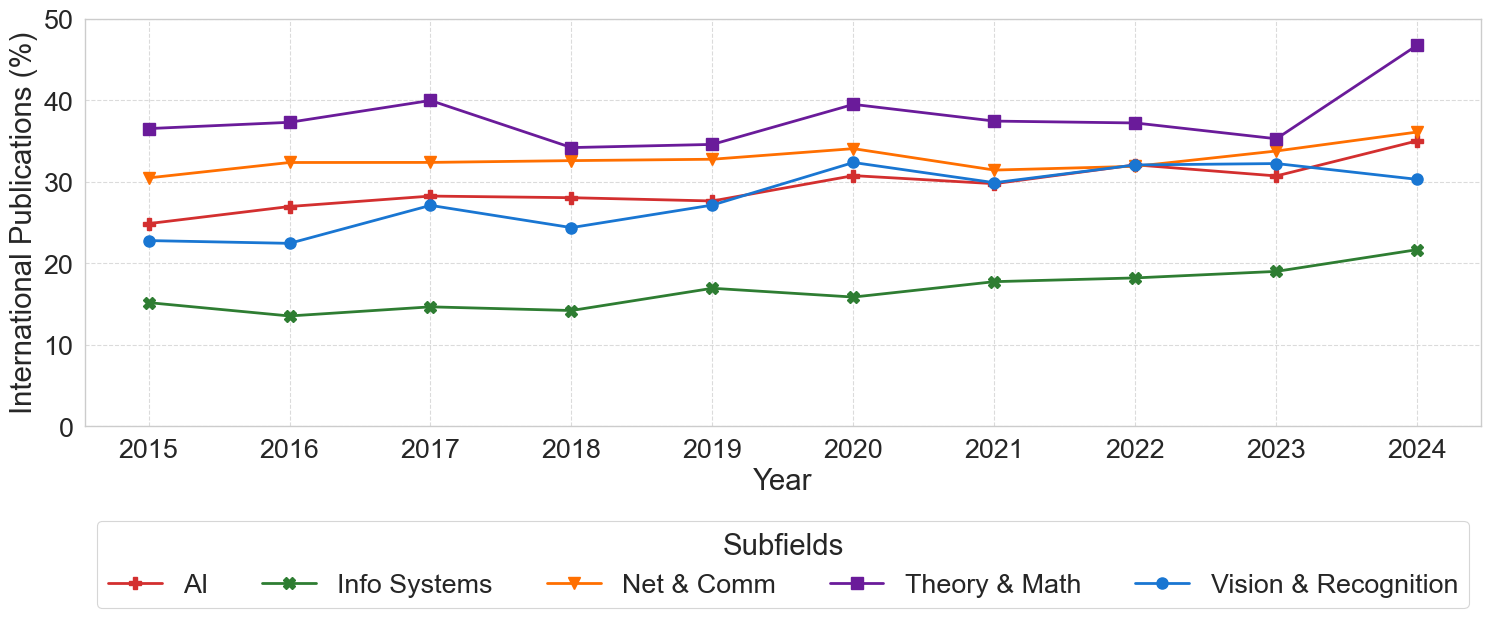

In [19]:
# 1. Read and prepare the data
international_df = pd.read_csv(INPUT_PATH)

# Convert year to string and pivot to wide format
wide_df = international_df.pivot(
    index='subfield_display',
    columns='publication_year', 
    values='international_percentage'
).astype(float)

# Convert column names to strings
wide_df.columns = wide_df.columns.astype(str)

# 2. Generate the years list from actual data
YEARS = sorted(wide_df.columns.tolist())

total_publications = international_df.groupby('subfield_display')['total_publications'].sum()

# 3. Plot using the corrected data
plot_international_trends(wide_df, YEARS, total_publications=total_publications)
plt.show()